# **PHYSICALLY INFORMED DOS PREDICTICTION - $SrTiO_3$ DATASET**

## Mounting The Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Installing Dependencies

In [1]:
!pip install torch torchvision

In [1]:
import torch
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

torch version: 2.3.0+cu121
CUDA available: True
CUDA version: 12.1


In [3]:
# Installing required packages
# To ensure compatibility with PyTorch Geometric's pre-compiled wheels for CUDA 12.x in Colab,
# it's often necessary to install a specific, known-working PyTorch version.
# We will install PyTorch 2.3.0 with CUDA 12.1 (which works with Colab's CUDA 12.8 drivers).
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121

# Install torch-scatter and torch-sparse (these will likely install numpy 2.x and scipy 1.18.0 initially)
!pip install torch-scatter torch-sparse torch-cluster torch-geometric torch-spline-conv -f https://data.pyg.org/whl/torch-2.3.0+cu121.html --force-reinstall

# Install other dependencies like matminer, pymatgen, ase
!pip install matminer pymatgen ase

# Fix for numpy/scipy incompatibility: Forcefully downgrade numpy and scipy LAST
# This addresses the ImportError: cannot import name '_center' from 'numpy._core.umath'
# by ensuring that numpy 1.x and a compatible scipy version are the final installed versions.
# We'll use scipy==1.17.0 as it's the minimum required by pymatgen and is compatible with numpy 1.x.
!pip install numpy==1.26.4 scipy==1.17.0 --force-reinstall

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 810.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 125.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 199.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 262.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 133.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 49.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 58.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 112.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 134.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 117.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.

Looking in links: https://data.pyg.org/whl/torch-2.3.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 82.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 24.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 78.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.6/949.6 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.6 MB/s eta 0:00:00
  Create

In [2]:
pwd

'/content'

In [3]:
cd drive/MyDrive/MatDeepLearn_DOS/

/content/drive/MyDrive/MatDeepLearn_DOS


In [4]:
# !git clone https://github.com/vxfung/MatDeepLearn_DOS # Only if repo is not cloned
# !cd MatDeepLearn_DOS
!pip install numpy scipy matplotlib joblib dscribe scikit_learn ase pymatgen ray PyYAML pickle
!pip install ray
!pip install dscribe
!pip install PyYAML
!pip install pickle


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle
  Using cached ray-2.57.0-cp312-cp312-manylinux2014_x86_64.whl.metadata (23 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 MB 10.1 MB/s eta 0:00:00
  Using cached dscribe-2.1.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.4/777.4 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 11.5 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


## Pre-Processing

In [5]:
pwd

'/content/drive/MyDrive/MatDeepLearn_DOS'

In [6]:
cd data


/content/drive/MyDrive/MatDeepLearn_DOS/data


In [7]:
ls

alloy_data/  bulk_dos/  srtio3_data/  surface_dos/
bulk_data/   README.md  STO_dos/


In [8]:
cd srtio3_data

/content/drive/MyDrive/MatDeepLearn_DOS/data/srtio3_data


In [9]:
ls

best_model.pt  data/  STO_DOS_dataset.tar.gz


In [12]:
# Copy your already-downloaded SrTiO3 data into a location main.py can point to
# !mkdir -p /content/MatDeepLearn_DOS/run_data
!mkdir -p /content/drive/MyDrive/MatDeepLearn_DOS/run_data
!cp data/*.vasp data/*.npy data/targets.csv /content/drive/MyDrive/MatDeepLearn_DOS/run_data/
!ls /content/drive/MyDrive/MatDeepLearn_DOS/run_data | wc -l   # should be ~9973 (4986*2 + targets.csv)

9973


In [13]:
cd ..

/content/drive/MyDrive/MatDeepLearn_DOS/data


In [14]:
cd ..

/content/drive/MyDrive/MatDeepLearn_DOS


In [15]:
# Editing config.yml - disabling SOAP/LMBTR since DOS_STO (DOSpredict model) doesn't use them
import re

config_path = "/content/drive/MyDrive/MatDeepLearn_DOS/config.yml"
with open(config_path, "r") as f:
    config_text = f.read()

config_text = config_text.replace('SOAP_descriptor: "True"', 'SOAP_descriptor: "False"')
config_text = config_text.replace('LMBTR_descriptor: "True"', 'LMBTR_descriptor: "False"')

with open(config_path, "w") as f:
    f.write(config_text)

# Verify the change took
!grep -A0 "SOAP_descriptor\|LMBTR_descriptor" /content/drive/MyDrive/MatDeepLearn_DOS/config.yml

    LMBTR_descriptor: "False"
--
    SOAP_descriptor: "False"


## Training Process

In [16]:
!python /content/drive/MyDrive/MatDeepLearn_DOS/main.py --data_path='/content/drive/MyDrive/MatDeepLearn_DOS/run_data' --model='DOS_STO' --run_mode='Training' --job_name='reproduce_srtio3' --save_model='True' --model_path='srtio3_model.pth'

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
Starting...
GPU is available: True , Quantity:  1
Settings: 
{'Job': {'job_name': 'reproduce_srtio3',
         'load_model': 'False',
         'model': 'DOS_STO',
         'model_path': 'srtio3_model.pth',
         'parallel': 'True',
         'reprocess': 'False',
         'save_model': 'True',
         'seed': 818149,
         'write_output': 'True'},
 'Models': {'batch_norm': 'True',
            'batch_size': 180,
            'batch_track_stats': 'False',
            'dim1': 370,
            'dim2': 370,
            'dropout_rate': 0.05,
            'epochs': 2000,
            'gc_count': 9,
            'lr': 0.00047,
            'model': 'DOSpredict',
            'optimizer': 'AdamW',
            'optimizer_args': {'weight_decay': 0.1},
            'pre_fc_cou

In [8]:
pwd

'/content/drive/MyDrive/MatDeepLearn_DOS'

## Analyzing Outputs

### Analyzing Predicted DOS Output

In [9]:
import pandas as pd
import numpy as np

df_main = pd.read_csv("reproduce_srtio3_test_outputs.csv")
print("Shape:", df_main.shape)
print("Columns (first 15):", df_main.columns[:15].tolist())
print("Columns (last 10):", df_main.columns[-10:].tolist())
df_main.head()

Shape: (3734, 806)
Columns (first 15): ['ids', 'element', 'loss_l1', 'loss_rmse', 'target', 'target.1', 'target.2', 'target.3', 'target.4', 'target.5', 'target.6', 'target.7', 'target.8', 'target.9', 'target.10']
Columns (last 10): ['prediction.391', 'prediction.392', 'prediction.393', 'prediction.394', 'prediction.395', 'prediction.396', 'prediction.397', 'prediction.398', 'prediction.399', 'prediction.400']


,ids,element,loss_l1,loss_rmse,target,target.1,target.2,target.3,target.4,target.5,...,prediction.391,prediction.392,prediction.393,prediction.394,prediction.395,prediction.396,prediction.397,prediction.398,prediction.399,prediction.400
0,2973,38,0.017100,0.054531,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000002,0.000008,0.000003,0.000002,0.000002,0.000009,0.000001,0.000005,NaN,NaN
1,2973,8,0.016820,0.031617,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000005,0.000004,0.000007,0.000004,0.000006,0.000008,0.000006,0.000004,NaN,NaN
2,2973,8,0.024408,0.048085,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000005,0.000003,0.000006,0.000004,0.000005,0.000004,0.000006,0.000005,NaN,NaN
3,2973,8,0.039675,0.090460,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000009,0.000010,0.000008,0.000012,0.000007,0.000010,0.000008,0.000011,NaN,NaN
4,2973,22,0.115376,0.227868,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000013,0.000012,0.000014,0.000013,0.000012,0.000022,0.000014,0.000014,NaN,NaN


### Analyzing Predicted DOS Derived Features Output

In [10]:
df_feat = pd.read_csv("reproduce_srtio3_test_outputs_features.csv")
print("Shape:", df_feat.shape)
print("Columns:", df_feat.columns.tolist())
df_feat.head()

Shape: (3734, 17)
Columns: ['ids', 'element', 'loss_l1', 'loss_l1.1', 'loss_l1.2', 'loss_l1.3', 'loss_l1.4', 'target', 'target.1', 'target.2', 'target.3', 'target.4', 'prediction', 'prediction.1', 'prediction.2', 'prediction.3', 'prediction.4']


,ids,element,loss_l1,loss_l1.1,loss_l1.2,loss_l1.3,loss_l1.4,target,target.1,target.2,target.3,target.4,prediction,prediction.1,prediction.2,prediction.3,prediction.4
0,2973,38,0.038574,0.110372,0.032350,0.065737,0.002273,3.302578,14.539617,-1.045950,2.570843,0.035043,3.341152,14.429245,-1.078300,2.636580,0.032771
1,2973,8,0.013609,0.015965,0.013266,0.006509,0.001590,-1.323617,5.600128,1.439892,5.003206,0.607510,-1.310008,5.584163,1.453158,5.009715,0.605920
2,2973,8,0.009316,0.043320,0.013085,0.032151,0.009720,-1.564360,7.276569,1.355948,4.484740,0.443125,-1.555044,7.233249,1.342863,4.452589,0.452845
3,2973,8,0.066372,0.114685,0.025927,0.062350,0.016899,-3.292579,11.022524,1.356758,4.115219,0.072860,-3.226207,11.137209,1.330831,4.052868,0.089759
4,2973,22,0.004344,0.006041,0.008536,0.013756,0.013490,0.766697,15.166100,-0.690725,2.122170,0.156126,0.771040,15.160059,-0.699261,2.135926,0.142636


### Refining The Outputs

In [11]:
# Ignore the mislabeled headers entirely - the real underlying data is simply:
# columns 0-3 = metadata (ids, element, loss_l1, loss_rmse)
# columns 4-403 = real target values (400 of them)
# columns 404-803 = real prediction values (400 of them)
# columns 804-805 = genuinely empty (NaN), an artifact of the header's off-by-one bug

meta = df_main.iloc[:, 0:4]
meta.columns = ["ids", "element", "loss_l1", "loss_rmse"]

targets = df_main.iloc[:, 4:404].values      # (3734, 400)
predictions = df_main.iloc[:, 404:804].values  # (3734, 400)

print("targets shape:", targets.shape, "| NaN present:", np.isnan(targets).any())
print("predictions shape:", predictions.shape, "| NaN present:", np.isnan(predictions).any())

ids = meta["ids"].values
elements = meta["element"].values
loss_l1_per_atom = meta["loss_l1"].values   # already-computed per-atom MAE, straight from their code

targets shape: (3734, 400) | NaN present: False
predictions shape: (3734, 400) | NaN present: False


## DOS Derived Features MAE Prediction

In [23]:
feature_names = ["band_center", "band_width", "skew", "kurtosis", "states_near_ef"]
loss_l1_cols = ["loss_l1", "loss_l1.1", "loss_l1.2", "loss_l1.3", "loss_l1.4"]

# This IS the paper's Table 1 "derived feature MAE" - just average each column
# across the whole test set, exactly like L_DOS was averaged to get 0.038
feature_mae = df_feat[loss_l1_cols].mean()
feature_mae.index = feature_names

print("Reproduced feature MAEs (compare to Table 1's SrTiO3 row):")
print(f"{'Feature':<18}{'Yours':<10}{'Paper':<10}")
paper_values = {"band_center": 0.052, "band_width": 0.154, "skew": 0.024,
                 "kurtosis": 0.056, "states_near_ef": 0.022}
for name in feature_names:
    print(f"{name:<18}{feature_mae[name]:<10.4f}{paper_values[name]:<10.4f}")

Reproduced feature MAEs (compare to Table 1's SrTiO3 row):
Feature           Yours     Paper     
band_center       0.0360    0.0520    
band_width        0.1035    0.1540    
skew              0.0159    0.0240    
kurtosis          0.0339    0.0560    
states_near_ef    0.0168    0.0220    


# Plotting

### Selecting An Id

In [13]:
import matplotlib.pyplot as plt

# Group per-atom MAE by structure id, find the structure with median mean-error
# (matches paper's "selected sample with median loss from the SrTiO3 dataset")
df_main_clean = meta.copy()
df_main_clean["targets_arr"] = list(targets)
df_main_clean["predictions_arr"] = list(predictions)

struct_mean_mae = df_main_clean.groupby("ids")["loss_l1"].mean().sort_values()
median_pos = len(struct_mean_mae) // 2
median_struct_id = struct_mean_mae.index[median_pos]
median_mae_value = struct_mean_mae.iloc[median_pos]

print(f"Selected structure_id={median_struct_id} with mean per-atom MAE={median_mae_value:.4f} "
      f"(median across {len(struct_mean_mae)} test structures)")

Selected structure_id=2707 with mean per-atom MAE=0.0362 (median across 747 test structures)


### Calculating L_features Per Atom

#### Strontium (Sr)

In [14]:
# --- Strontium (Sr, Z=38) ---
Sr_Z = 38
loss_l1_cols = ["loss_l1", "loss_l1.1", "loss_l1.2", "loss_l1.3", "loss_l1.4"]
feature_names = ["band_center", "band_width", "skew", "kurtosis", "states_near_ef"]

struct_Sr_rows = df_feat[(df_feat["ids"] == median_struct_id) & (df_feat["element"] == Sr_Z)]

print(f"=== Sr atom(s) in structure {median_struct_id} ===")
print(f"Number of Sr atoms found: {len(struct_Sr_rows)}\n")

# Individual breakdown (per-feature errors, per atom)
print("Individual per-feature errors:")
print(struct_Sr_rows[loss_l1_cols].rename(columns=dict(zip(loss_l1_cols, feature_names))))

# Individual L_features (sum of 5) per atom
struct_Sr_rows_Lfeat = struct_Sr_rows[loss_l1_cols].sum(axis=1)
print("\nIndividual L_features (sum of 5) per Sr atom:")
print(struct_Sr_rows_Lfeat)

# Averaged L_features across all Sr atoms in this structure
print(f"\nAveraged L_features across Sr atoms: {struct_Sr_rows_Lfeat.mean():.4f}")

=== Sr atom(s) in structure 2707 ===
Number of Sr atoms found: 1

Individual per-feature errors:
      band_center  band_width      skew  kurtosis  states_near_ef
3580     0.004016    0.027026  0.007802  0.023137         0.00064

Individual L_features (sum of 5) per Sr atom:
3580    0.062622
dtype: float64

Averaged L_features across Sr atoms: 0.0626


#### Titanium (Ti)

In [15]:
# --- Titanium (Ti, Z=22) ---
Ti_Z = 22

struct_Ti_rows = df_feat[(df_feat["ids"] == median_struct_id) & (df_feat["element"] == Ti_Z)]

print(f"=== Ti atom(s) in structure {median_struct_id} ===")
print(f"Number of Ti atoms found: {len(struct_Ti_rows)}\n")

print("Individual per-feature errors:")
print(struct_Ti_rows[loss_l1_cols].rename(columns=dict(zip(loss_l1_cols, feature_names))))

struct_Ti_rows_Lfeat = struct_Ti_rows[loss_l1_cols].sum(axis=1)
print("\nIndividual L_features (sum of 5) per Ti atom:")
print(struct_Ti_rows_Lfeat)

print(f"\nAveraged L_features across Ti atoms: {struct_Ti_rows_Lfeat.mean():.4f}")

=== Ti atom(s) in structure 2707 ===
Number of Ti atoms found: 1

Individual per-feature errors:
      band_center  band_width     skew  kurtosis  states_near_ef
3584     0.005819    0.018184  0.01091  0.009527        0.000687

Individual L_features (sum of 5) per Ti atom:
3584    0.045128
dtype: float64

Averaged L_features across Ti atoms: 0.0451


#### Oxygen (O)

In [16]:
# --- Oxygen (O, Z=8) ---
O_Z = 8

struct_O_rows = df_feat[(df_feat["ids"] == median_struct_id) & (df_feat["element"] == O_Z)]

print(f"=== O atom(s) in structure {median_struct_id} ===")
print(f"Number of O atoms found: {len(struct_O_rows)}\n")

print("Individual per-feature errors:")
print(struct_O_rows[loss_l1_cols].rename(columns=dict(zip(loss_l1_cols, feature_names))))

struct_O_rows_Lfeat = struct_O_rows[loss_l1_cols].sum(axis=1)
print("\nIndividual L_features (sum of 5) per O atom:")
print(struct_O_rows_Lfeat)

print(f"\nAveraged L_features across O atoms: {struct_O_rows_Lfeat.mean():.4f}")

=== O atom(s) in structure 2707 ===
Number of O atoms found: 3

Individual per-feature errors:
      band_center  band_width      skew  kurtosis  states_near_ef
3581     0.010840    0.003172  0.002561  0.002344        0.005727
3582     0.017234    0.008432  0.000404  0.005730        0.003136
3583     0.007484    0.022744  0.006206  0.000365        0.016613

Individual L_features (sum of 5) per O atom:
3581    0.024643
3582    0.034936
3583    0.053412
dtype: float64

Averaged L_features across O atoms: 0.0377


### The Plot

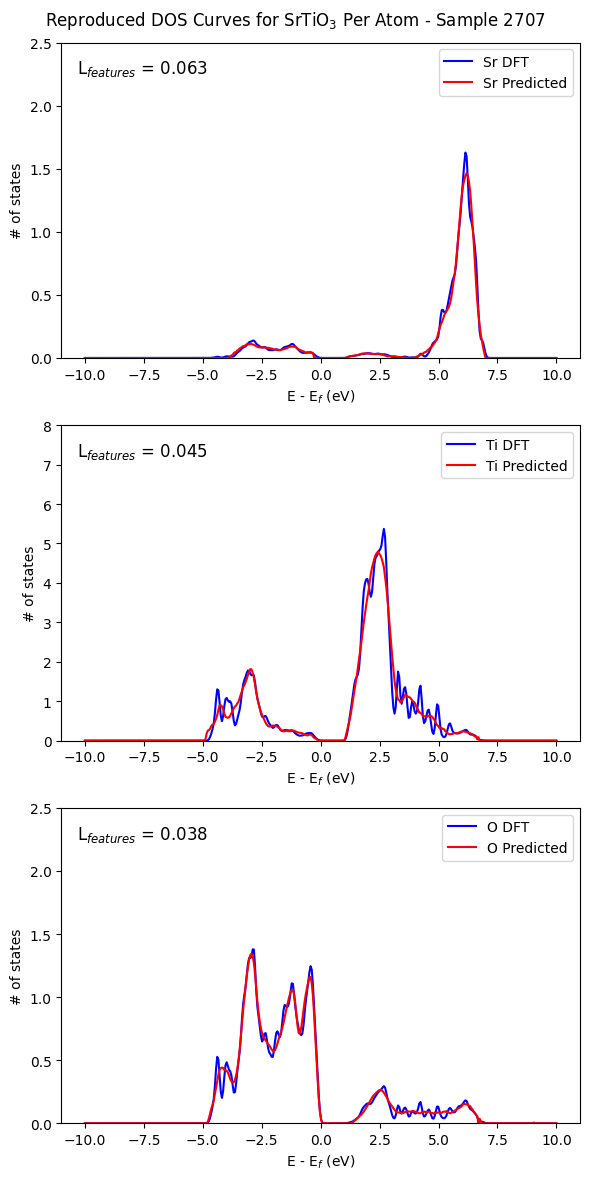

In [21]:
Z_TO_SYMBOL = {8: "O", 22: "Ti", 38: "Sr"}
Z_TO_YLIM = {8: (0, 2.5), 22: (0, 8), 38: (0, 2.5)}  # matching paper's Figure 2 axis ranges

loss_l1_cols = ["loss_l1", "loss_l1.1", "loss_l1.2", "loss_l1.3", "loss_l1.4"]

energies = np.linspace(-10, 10, 400)

struct_mask = df_main_clean["ids"] == median_struct_id
struct_rows = df_main_clean[struct_mask]

# also pull this structure's feature-loss rows, to compute L_features per element
struct_feat_rows = df_feat[df_feat["ids"] == median_struct_id]

unique_elements = sorted(struct_rows["element"].unique(), key=lambda z: -z)  # heaviest first

fig, axes = plt.subplots(len(unique_elements), 1, figsize=(6, 4 * len(unique_elements)))
if len(unique_elements) == 1:
    axes = [axes]

for ax, z in zip(axes, unique_elements):
    elem_rows = struct_rows[struct_rows["element"] == z]

    # average curves if multiple atoms of same element (e.g. 3x O)
    true_curve = np.stack(elem_rows["targets_arr"].values).mean(axis=0)
    pred_curve = np.stack(elem_rows["predictions_arr"].values).mean(axis=0)

    # --- compute this element's L_features (sum of 5 feature losses), averaged
    #     across atoms of this element in this structure ---
    elem_feat_rows = struct_feat_rows[struct_feat_rows["element"] == z]
    L_features_value = elem_feat_rows[loss_l1_cols].sum(axis=1).mean()

    label = Z_TO_SYMBOL.get(z, f"Z={z}")
    ax.plot(energies, true_curve, color="blue", label=f"{label} DFT")
    ax.plot(energies, pred_curve, color="red", label=f"{label} Predicted")
    ax.set_xlabel("E - E$_f$ (eV)")
    ax.set_ylabel("# of states")
    ax.legend()
    if z in Z_TO_YLIM:
        ax.set_ylim(*Z_TO_YLIM[z])

    # --- annotate L_features on the plot, top-left, matching paper's style ---
    ax.text(0.03, 0.95, f"L$_{{features}}$ = {L_features_value:.3f}",
            transform=ax.transAxes, fontsize=12,
            verticalalignment="top", horizontalalignment="left")

plt.suptitle(f"Reproduced DOS Curves for SrTiO$_3$ Per Atom - Sample {median_struct_id}")
plt.tight_layout()
plt.savefig("figure2_official_reproduction.png", dpi=200)
plt.show()

# Calculating Coefficient Of Determination $R^2$

$R^2$ answers the question: "of all the variation that exists in the true DOS values (means, how different are the true DOS values from each other, across the whole dataset?), what fraction does my model's predictions successfully capture?

In [20]:
def r_squared(true, pred):
    true_flat = true.flatten()
    pred_flat = pred.flatten()
    ss_res = np.sum((true_flat - pred_flat) ** 2)
    ss_tot = np.sum((true_flat - np.mean(true_flat)) ** 2)
    return 1 - ss_res / ss_tot

r2_dos = r_squared(targets, predictions)
print(f"DOS curve R² = {r2_dos:.4f}  →  {r2_dos*100:.2f}% of variance explained")

DOS curve R² = 0.9478  →  94.78% of variance explained
